# Chapter 5: Data Exploration 2

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
from matplotlib import pyplot as plt

## 5.1 Introduction & Problem Setting

Now that you know quite a bit about analysing data, it's time to put this into practise! Today you will be analysing the 'Air crash dataset', an interesting dataset containing lots of information about different airplane crashes since 1908. You'll be looking at the data and hopefully make some interesting discoveries/conclusions!

During this exercise you will be comparing two operators: 'Aeroflot' and 'Military - U.S. Air Force'.

## 5.2 Data Loading & exploration

First, load in the data. Explore it by looking at the columns, datatypes, size, null values, ...

Also, create your two subsets, one for each of the operators you will be comparing ('Aeroflot' and 'Military - U.S. Air Force')

In [2]:
crash = pd.read_csv("Airplane_Crashes_and_Fatalities_Since_1908.csv")
crash.head()

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
0,09/17/1908,17:18,"Fort Myer, Virginia",Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,1,2.0,1.0,0.0,"During a demonstration flight, a U.S. Army fly..."
1,07/12/1912,06:30,"AtlantiCity, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...
2,08/06/1913,NaN,"Victoria, British Columbia, Canada",Private,-,NaN,Curtiss seaplane,NaN,NaN,1.0,1.0,0.0,The first fatal airplane accident in Canada oc...
3,09/09/1913,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,14.0,0.0,The airship flew into a thunderstorm and encou...
4,10/17/1913,10:30,"Near Johannisthal, Germany",Military - German Navy,NaN,NaN,Zeppelin L-2 (airship),NaN,NaN,30.0,30.0,0.0,Hydrogen gas which was being vented was sucked...


In [3]:
crash.dtypes

Date             object
Time             object
Location         object
Operator         object
Flight #         object
Route            object
Type             object
Registration     object
cn/In            object
Aboard          float64
Fatalities      float64
Ground          float64
Summary          object
dtype: object

In [4]:
airplane_subset = crash[(crash["Operator"]=="Aeroflot")|(crash["Operator"]=="Military - U.S. Army")]
airplane_subset

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
0,09/17/1908,17:18,"Fort Myer, Virginia",Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,1,2.0,1.0,0.0,"During a demonstration flight, a U.S. Army fly..."
643,03/22/1944,NaN,New Guinea,Military - U.S. Army,NaN,Port Moreaby - Nadzab,Consolidated B-24 Liberator,NaN,NaN,21.0,21.0,NaN,Disappeared while en route on a non-combat mis...
746,11/11/1945,NaN,Himalayas,Military - U.S. Army,NaN,"Chabau, India - Karachi, Pakistan",Douglas C-54,NaN,NaN,44.0,44.0,0.0,Crashed into a mountain ridge 200 ft. short of...
751,12/08/1945,NaN,"Near Billings, Montana",Military - U.S. Army,NaN,"Newark, N.J. - Seattle, WA",Douglas C-47,NaN,NaN,21.0,17.0,0.0,Crashed into a field after hitting trees while...
825,12/04/1946,NaN,"Meshed, Iran",Aeroflot,NaN,Meshed - Teheran,Lisunov Li-2,NaN,NaN,24.0,24.0,0.0,Crashed shortly after takeoff from Meshed airp...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4845,02/22/2002,02:30,"Off Dumaguete, Philippines",Military - U.S. Army,-,Basilan - Mactan Island,MH-47 Chinook helicopter,92-0471,M-3719,10.0,10.0,0.0,A helicopter ferrying U.S. troops in a counter...
4900,11/15/2003,18:30,"Mosul, Iraq",Military - U.S. Army,NaN,NaN,UH-60 Black Hawk / UH-60 Black Hawk,/,NaN,22.0,17.0,0.0,A midair collision occurred between two Black ...
4958,11/02/2003,09:00,"Near Hasi, Iraq",Military - U.S. Army,-,Fallujah - Baghdad,CH-47 Chinook,NaN,NaN,36.0,15.0,0.0,The helicopter crashed into a corn field while...
5166,08/22/2007,NaN,"Near Kirkuk, Iraq",Military - U.S. Army,NaN,Transporting troops,UH-60 Blackhawk helilcopter,NaN,NaN,14.0,14.0,0.0,Crashed most likely due to a mechanical proble...


## 5.3: Excercises

### 5.3.1: Make a histogram of both datasets and compare them. We are only interested in the amount of fatalities per operator. What does this tell you?

In [5]:
newdf = airplane_subset.groupby("Operator",as_index=False).agg(Fatalities=("Fatalities","sum"))
newdf

,Operator,Fatalities
0,Aeroflot,7156.0
1,Military - U.S. Army,498.0


/var/folders/76/z1mjvk1s7k36fwnyfkcvx1q40000gn/T/ipykernel_12680/3382406595.py:2: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


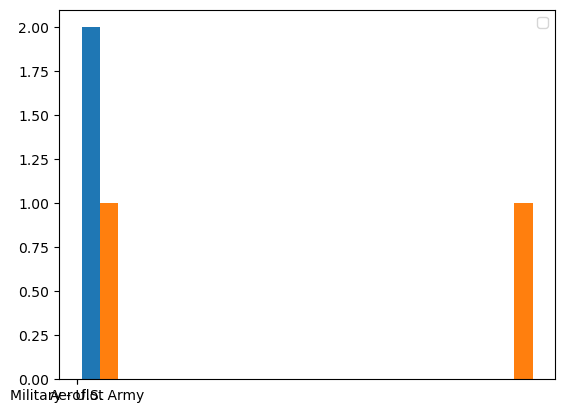

In [6]:
plt.hist(newdf)
plt.legend()
plt.show()

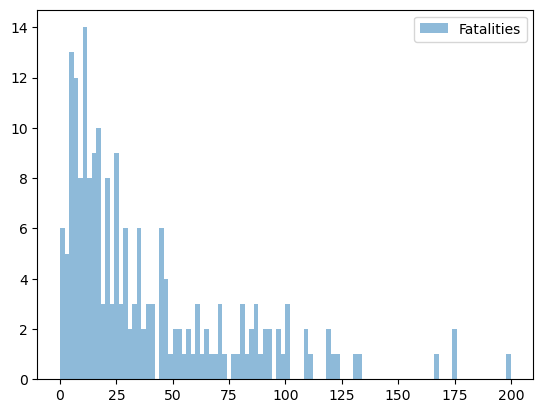

In [7]:
plt.hist(airplane_subset["Fatalities"],density=False,bins=100,label='Fatalities',alpha=0.5)
plt.legend()
plt.show()

### 5.3.2: Make a boxplot to compare the data. Does this give you any more information?

- Which one has one average more deaths?
- Do the medians tell the same story?
- What about the standard deviation/IQR

In [8]:
Mean = np.mean(airplane_subset["Fatalities"])
Median = np.median(airplane_subset["Fatalities"])
stddev = np.sqrt(np.var(airplane_subset["Fatalities"]))
print(Mean)
print(Median)
print(stddev)


37.89108910891089
24.0
37.8492060133835


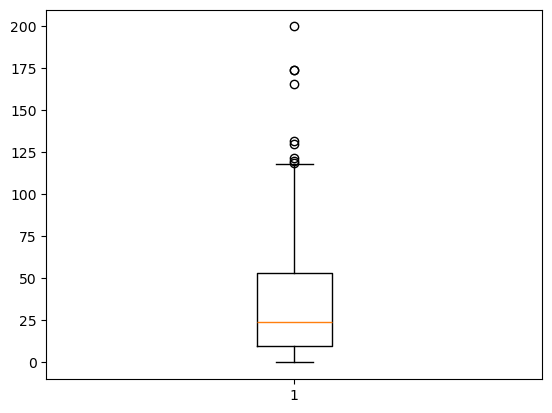

In [9]:
boxplot_data=airplane_subset["Fatalities"]
plt.boxplot(boxplot_data)
plt.show()


### 5.3.3: Calculate the proportion of passengers killed in the crash. Make a boxplot out of this data for both US military and Aeroflot. What can you conclude?

In [10]:
airplane_subset["Killed"] = airplane_subset["Fatalities"]/airplane_subset["Aboard"]
airplane_subset

/var/folders/76/z1mjvk1s7k36fwnyfkcvx1q40000gn/T/ipykernel_12680/378582270.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  airplane_subset["Killed"] = airplane_subset["Fatalities"]/airplane_subset["Aboard"]


,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary,Killed
0,09/17/1908,17:18,"Fort Myer, Virginia",Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,1,2.0,1.0,0.0,"During a demonstration flight, a U.S. Army fly...",0.500000
643,03/22/1944,NaN,New Guinea,Military - U.S. Army,NaN,Port Moreaby - Nadzab,Consolidated B-24 Liberator,NaN,NaN,21.0,21.0,NaN,Disappeared while en route on a non-combat mis...,1.000000
746,11/11/1945,NaN,Himalayas,Military - U.S. Army,NaN,"Chabau, India - Karachi, Pakistan",Douglas C-54,NaN,NaN,44.0,44.0,0.0,Crashed into a mountain ridge 200 ft. short of...,1.000000
751,12/08/1945,NaN,"Near Billings, Montana",Military - U.S. Army,NaN,"Newark, N.J. - Seattle, WA",Douglas C-47,NaN,NaN,21.0,17.0,0.0,Crashed into a field after hitting trees while...,0.809524
825,12/04/1946,NaN,"Meshed, Iran",Aeroflot,NaN,Meshed - Teheran,Lisunov Li-2,NaN,NaN,24.0,24.0,0.0,Crashed shortly after takeoff from Meshed airp...,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4845,02/22/2002,02:30,"Off Dumaguete, Philippines",Military - U.S. Army,-,Basilan - Mactan Island,MH-47 Chinook helicopter,92-0471,M-3719,10.0,10.0,0.0,A helicopter ferrying U.S. troops in a counter...,1.000000
4900,11/15/2003,18:30,"Mosul, Iraq",Military - U.S. Army,NaN,NaN,UH-60 Black Hawk / UH-60 Black Hawk,/,NaN,22.0,17.0,0.0,A midair collision occurred between two Black ...,0.772727
4958,11/02/2003,09:00,"Near Hasi, Iraq",Military - U.S. Army,-,Fallujah - Baghdad,CH-47 Chinook,NaN,NaN,36.0,15.0,0.0,The helicopter crashed into a corn field while...,0.416667
5166,08/22/2007,NaN,"Near Kirkuk, Iraq",Military - U.S. Army,NaN,Transporting troops,UH-60 Blackhawk helilcopter,NaN,NaN,14.0,14.0,0.0,Crashed most likely due to a mechanical proble...,1.000000


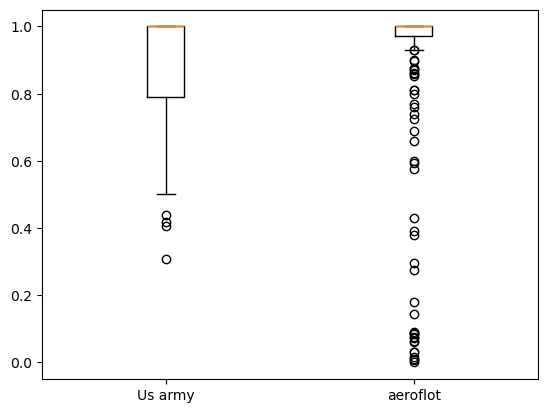

In [11]:
boxplot_data = [
    airplane_subset[airplane_subset["Operator"]=="Military - U.S. Army"]["Killed"],
    airplane_subset[airplane_subset["Operator"]=="Aeroflot"]["Killed"]
]

plt.boxplot(boxplot_data,tick_labels=("Us army","aeroflot"))
plt.show()